# Data Preparation

## 1. Import Libraries

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

## 2. Load Dataset

In [2]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

# Reproducible project paths for the Google Drive / Colab version
BASE_DIR = Path("/content/drive/MyDrive/CMP7005_project/reproducible")
PROJECT_DIR = BASE_DIR.parent
DATA_DIR = PROJECT_DIR / "data"
FIG_DIR = BASE_DIR / "figures"
RESULT_DIR = BASE_DIR / "results"

FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# Prefer the cleaned dataset generated by the reproducible EDA notebook.
# If it is not available, fall back to the original data folder.
DATA_CANDIDATES = [
    RESULT_DIR / "combined_cleaned_air_quality.csv",
    DATA_DIR / "combined_cleaned_air_quality.csv",
    DATA_DIR / "combined_data.csv"
]

DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Cleaned dataset was not found. Please run the EDA reproducible notebook first, "
        "or check that combined_cleaned_air_quality.csv exists in the data/results folder."
    )

df = pd.read_csv(DATA_PATH)

df["datetime"] = pd.to_datetime(df["datetime"])

print("Loaded dataset from:", DATA_PATH)
print("Dataset shape:", df.shape)
df.head()


Mounted at /content/drive
Loaded dataset from: /content/drive/MyDrive/CMP7005_project/reproducible/results/combined_cleaned_air_quality.csv
Dataset shape: (140256, 28)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,datetime,year_num,month_num,day_num,hour_num,dayofweek,is_weekend,station_type,season,PM25_Level
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,...,2013-03-01 00:00:00,2013,3,1,0,Friday,False,Suburban,Spring,Good
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,...,2013-03-01 01:00:00,2013,3,1,1,Friday,False,Suburban,Spring,Good
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,...,2013-03-01 02:00:00,2013,3,1,2,Friday,False,Suburban,Spring,Good
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,...,2013-03-01 03:00:00,2013,3,1,3,Friday,False,Suburban,Spring,Good
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,...,2013-03-01 04:00:00,2013,3,1,4,Friday,False,Suburban,Spring,Good


## 3. Define Target Variable and Feature Groups

In [3]:
TARGET = "PM2.5"

STATION_ORDER = ["Changping", "Shunyi", "Tiantan", "Wanshouxigong"]

pollutant_cols = [c for c in ["PM10", "SO2", "NO2", "CO", "O3"] if c in df.columns]
weather_cols = [c for c in ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"] if c in df.columns]

print("Pollutant features:", pollutant_cols)
print("Weather features:", weather_cols)

Pollutant features: ['PM10', 'SO2', 'NO2', 'CO', 'O3']
Weather features: ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']


# Feature Engineering

## 4. Feature Engineering (Time & Lag Features)

In [4]:
df_model = df.copy()

df_model = df_model.sort_values(["station", "datetime"])

df_model["hour"] = df_model["datetime"].dt.hour
df_model["day"] = df_model["datetime"].dt.day
df_model["month"] = df_model["datetime"].dt.month
df_model["dayofweek"] = df_model["datetime"].dt.dayofweek
df_model["is_weekend"] = df_model["dayofweek"].isin([5, 6]).astype(int)

df_model["PM25_lag1"] = df_model.groupby("station")[TARGET].shift(1)
df_model["PM25_lag24"] = df_model.groupby("station")[TARGET].shift(24)

df_model["PM25_roll24"] = (
    df_model.groupby("station")[TARGET]
    .shift(1)
    .rolling(24)
    .mean()
)

df_model = df_model.dropna().reset_index(drop=True)

print("Model dataset shape:", df_model.shape)
df_model.head()

Model dataset shape: (140160, 31)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,day_num,hour_num,dayofweek,is_weekend,station_type,season,PM25_Level,PM25_lag1,PM25_lag24,PM25_roll24
0,25,2013,3,2,0,11.0,13.0,23.0,16.0,400.0,...,2,0,5,1,Suburban,Spring,Good,7.0,3.0,5.083333
1,26,2013,3,2,1,12.0,10.0,24.0,18.0,400.0,...,2,1,5,1,Suburban,Spring,Good,11.0,3.0,5.416667
2,27,2013,3,2,2,13.0,9.0,7.0,56.0,800.0,...,2,2,5,1,Suburban,Spring,Good,12.0,3.0,5.791667
3,28,2013,3,2,3,14.0,24.0,23.0,42.0,800.0,...,2,3,5,1,Suburban,Spring,Good,13.0,3.0,6.208333
4,29,2013,3,2,4,14.0,18.0,24.0,36.0,400.0,...,2,4,5,1,Suburban,Spring,Good,14.0,3.0,6.666667


## 5. Prepare Input Features and Target Variable

In [5]:
numeric_features = (
    pollutant_cols
    + weather_cols
    + ["hour", "day", "month", "dayofweek", "is_weekend", "PM25_lag1", "PM25_lag24", "PM25_roll24"]
)

categorical_features = [c for c in ["station", "wd", "season"] if c in df_model.columns]

features = numeric_features + categorical_features

X = df_model[features]
y = df_model[TARGET]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Total features:", len(features))

Numeric features: ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'hour', 'day', 'month', 'dayofweek', 'is_weekend', 'PM25_lag1', 'PM25_lag24', 'PM25_roll24']
Categorical features: ['station', 'wd', 'season']
Total features: 21


# Model Preparation

## 6. Train-Test Split (Time-Based)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (112128, 21)
Test size: (28032, 21)


## 7. Data Preprocessing Pipeline

In [7]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 8. Model Evaluation Function

In [8]:
model_results = []

def evaluate_model(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    result = {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

    model_results.append(result)
    return result

# Baseline & Machine Learning Models

## 9. Baseline Model (Mean Prediction)

In [9]:
baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mean())

baseline_result = evaluate_model(
    "Baseline Mean",
    y_test,
    baseline_pred
)

baseline_result

{'Model': 'Baseline Mean',
 'RMSE': np.float64(88.21023304960131),
 'MAE': 61.114137218912234,
 'R2': -0.006779070402199938}

## 10. Linear Regression Model

In [10]:
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)

lr_result = evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

lr_result

{'Model': 'Linear Regression',
 'RMSE': np.float64(19.392081965724536),
 'MAE': 11.181763737767493,
 'R2': 0.9513430238203429}

## 11. Random Forest Model

In [11]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=16,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

rf_result = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

rf_result

{'Model': 'Random Forest',
 'RMSE': np.float64(14.95697690813518),
 'MAE': 8.025152569684908,
 'R2': 0.9710543113799925}

## Model Improvement

## 12. Tuned Random Forest (Hyperparameter Optimization)

In [12]:
sample_size = min(30000, len(X_train))
X_train_sample = X_train.iloc[-sample_size:]
y_train_sample = y_train.iloc[-sample_size:]

rf_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

param_distributions = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [8, 12, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=5,
    scoring="neg_root_mean_squared_error",
    cv=2,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_search.fit(X_train_sample, y_train_sample)

best_params = rf_search.best_params_

print("Best parameters from sample search:")
print(best_params)

final_rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=best_params["model__n_estimators"],
        max_depth=best_params["model__max_depth"],
        min_samples_split=best_params["model__min_samples_split"],
        min_samples_leaf=best_params["model__min_samples_leaf"],
        max_features=best_params["model__max_features"],
        random_state=42,
        n_jobs=-1
    ))
])

final_rf_pipeline.fit(X_train, y_train)

best_rf_pred = final_rf_pipeline.predict(X_test)

rf_tuned_result = evaluate_model(
    "Tuned Random Forest",
    y_test,
    best_rf_pred
)

rf_tuned_result

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best parameters from sample search:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 12}


{'Model': 'Tuned Random Forest',
 'RMSE': np.float64(15.187344556366288),
 'MAE': 8.171055901933295,
 'R2': 0.9701558007057423}

# Model Evaluation & Visualisation

## 13. Model Prediction Comparison Plot

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/model_prediction_comparison.png


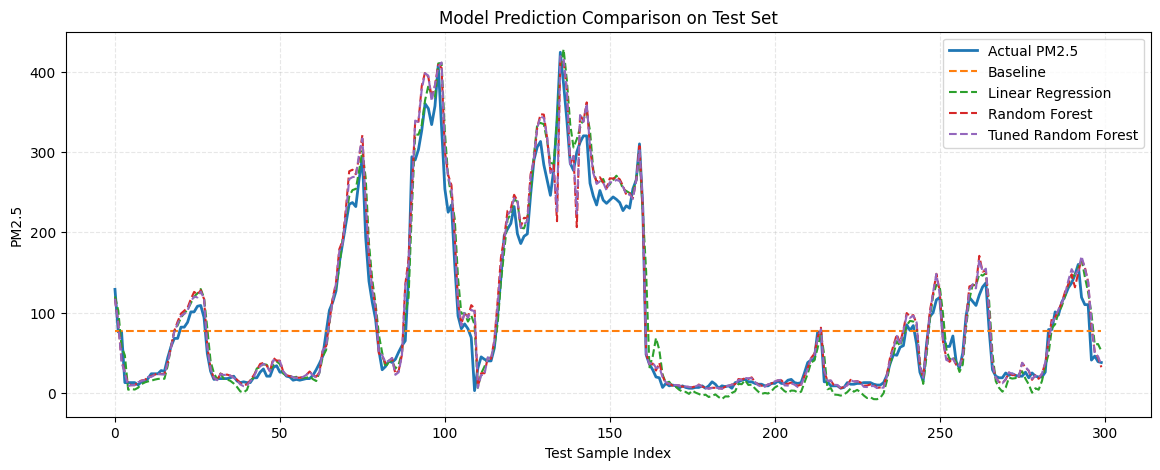

In [13]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Baseline": baseline_pred,
    "Linear Regression": lr_pred,
    "Random Forest": rf_pred,
    "Tuned Random Forest": best_rf_pred
})

sample_size = min(300, len(comparison_df))
plot_df = comparison_df.iloc[:sample_size]

plt.figure(figsize=(14, 5))

plt.plot(plot_df["Actual"].values, label="Actual PM2.5", linewidth=2)
plt.plot(plot_df["Baseline"].values, label="Baseline", linestyle="--")
plt.plot(plot_df["Linear Regression"].values, label="Linear Regression", linestyle="--")
plt.plot(plot_df["Random Forest"].values, label="Random Forest", linestyle="--")
plt.plot(plot_df["Tuned Random Forest"].values, label="Tuned Random Forest", linestyle="--")

plt.title("Model Prediction Comparison on Test Set")
plt.xlabel("Test Sample Index")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)

output_path = FIG_DIR / "model_prediction_comparison.png"
plt.savefig(output_path, bbox_inches="tight", dpi=300)

print("Saved:", output_path)

plt.show()
plt.close()

## 14. Model Performance Summary Table

In [14]:
results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values("RMSE").reset_index(drop=True)
display(results_df)

,Model,RMSE,MAE,R2
0,Random Forest,14.956977,8.025153,0.971054
1,Tuned Random Forest,15.187345,8.171056,0.970156
2,Linear Regression,19.392082,11.181764,0.951343
3,Baseline Mean,88.210233,61.114137,-0.006779


## 15. RMSE Comparison Across Models

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/model_comparison_rmse.png


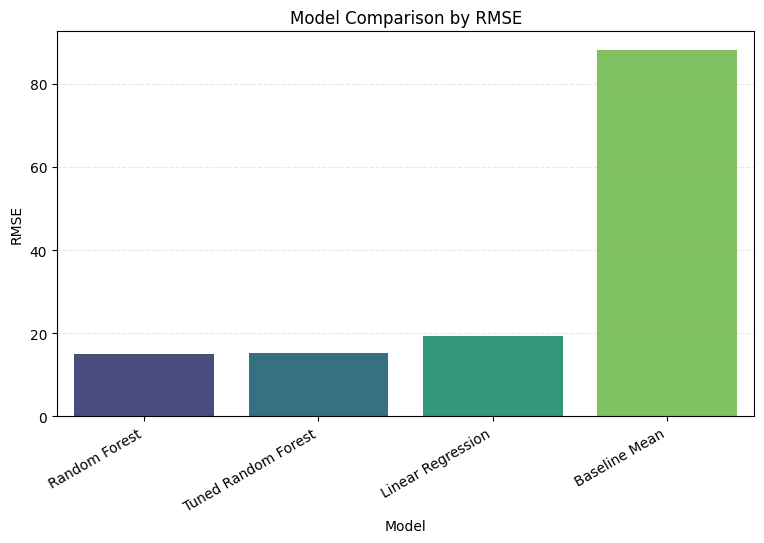

In [15]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE",
    palette="viridis"
)

plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)

output_path = FIG_DIR / "model_comparison_rmse.png"
plt.savefig(output_path, bbox_inches="tight", dpi=300)

print("Saved:", output_path)

plt.show()
plt.close()

# Model Interpretation

## 16. Feature Importance Analysis (Random Forest)

,Feature,Importance
15,num__PM25_lag1,0.887514
0,num__PM10,0.086374
3,num__CO,0.006803
1,num__SO2,0.003508
7,num__DEWP,0.002595
17,num__PM25_roll24,0.002594
16,num__PM25_lag24,0.001513
9,num__WSPM,0.001375
2,num__NO2,0.001145
6,num__PRES,0.001132


Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/random_forest_feature_importance.png


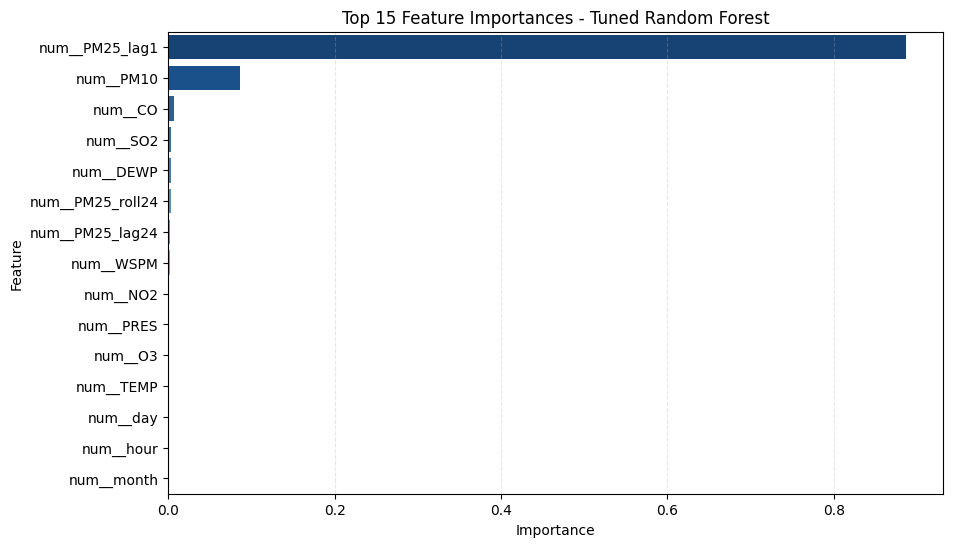

In [16]:
best_rf_model = final_rf_pipeline.named_steps["model"]
feature_names = final_rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature",
    palette="Blues_r"
)

plt.title("Top 15 Feature Importances - Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.3)

output_path = FIG_DIR / "random_forest_feature_importance.png"
plt.savefig(output_path, bbox_inches="tight", dpi=300)

print("Saved:", output_path)

plt.show()
plt.close()

# Time Series Modelling

## 17. SARIMAX Time Series Model

In [17]:
def build_daily_station_data(df, station_name, exog_cols):
    station_df = df[df["station"] == station_name].copy()

    agg_dict = {"PM2.5": "mean"}
    for col in exog_cols:
        agg_dict[col] = "mean"

    daily_data = (
        station_df
        .set_index("datetime")
        .resample("D")
        .agg(agg_dict)
    )

    daily_data = daily_data.interpolate(method="time")
    daily_data = daily_data.ffill().bfill()

    return daily_data


def evaluate_forecast(model_name, y_true, y_pred, station):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "Station": station,
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }


stations = [s for s in STATION_ORDER if s in df["station"].dropna().unique()]
exog_cols = weather_cols

sarimax_results = []
forecast_store = {}

for station_name in stations:
    print("Processing station:", station_name)

    daily_data = build_daily_station_data(df, station_name, exog_cols)

    split_idx = int(len(daily_data) * 0.8)

    train = daily_data.iloc[:split_idx]
    test = daily_data.iloc[split_idx:]

    y_train_ts = train["PM2.5"]
    y_test_ts = test["PM2.5"]

    X_train_ts = train[exog_cols]
    X_test_ts = test[exog_cols]

    baseline_ts_pred = pd.Series(
        y_train_ts.mean(),
        index=y_test_ts.index
    )

    sarimax_model = SARIMAX(
        y_train_ts,
        exog=X_train_ts,
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    sarimax_fitted = sarimax_model.fit(disp=False)

    sarimax_pred = sarimax_fitted.forecast(
        steps=len(y_test_ts),
        exog=X_test_ts
    )

    sarimax_pred.index = y_test_ts.index
    sarimax_pred = sarimax_pred.clip(lower=0)

    sarimax_results.append(
        evaluate_forecast("Time-Series Baseline Mean", y_test_ts, baseline_ts_pred, station_name)
    )

    sarimax_results.append(
        evaluate_forecast("SARIMAX + Weather", y_test_ts, sarimax_pred, station_name)
    )

    forecast_store[station_name] = {
        "Actual": y_test_ts,
        "Baseline": baseline_ts_pred,
        "SARIMAX": sarimax_pred
    }

sarimax_results_df = pd.DataFrame(sarimax_results)

display(sarimax_results_df)

Processing station: Changping
Processing station: Shunyi
Processing station: Tiantan
Processing station: Wanshouxigong


,Station,Model,RMSE,MAE,R2
0,Changping,Time-Series Baseline Mean,63.596718,45.493894,-0.003533
1,Changping,SARIMAX + Weather,95.873046,76.406750,-1.280632
2,Shunyi,Time-Series Baseline Mean,67.347905,48.513828,-0.003140
3,Shunyi,SARIMAX + Weather,109.362056,86.235742,-1.645128
4,Tiantan,Time-Series Baseline Mean,74.187615,51.795407,-0.000003
5,Tiantan,SARIMAX + Weather,101.379169,75.583240,-0.867393
6,Wanshouxigong,Time-Series Baseline Mean,80.205233,54.202063,-0.001263
7,Wanshouxigong,SARIMAX + Weather,109.443919,83.886801,-0.864344


## 18. SARIMAX Forecast Visualisation

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/sarimax_weather_forecast_all_stations.png


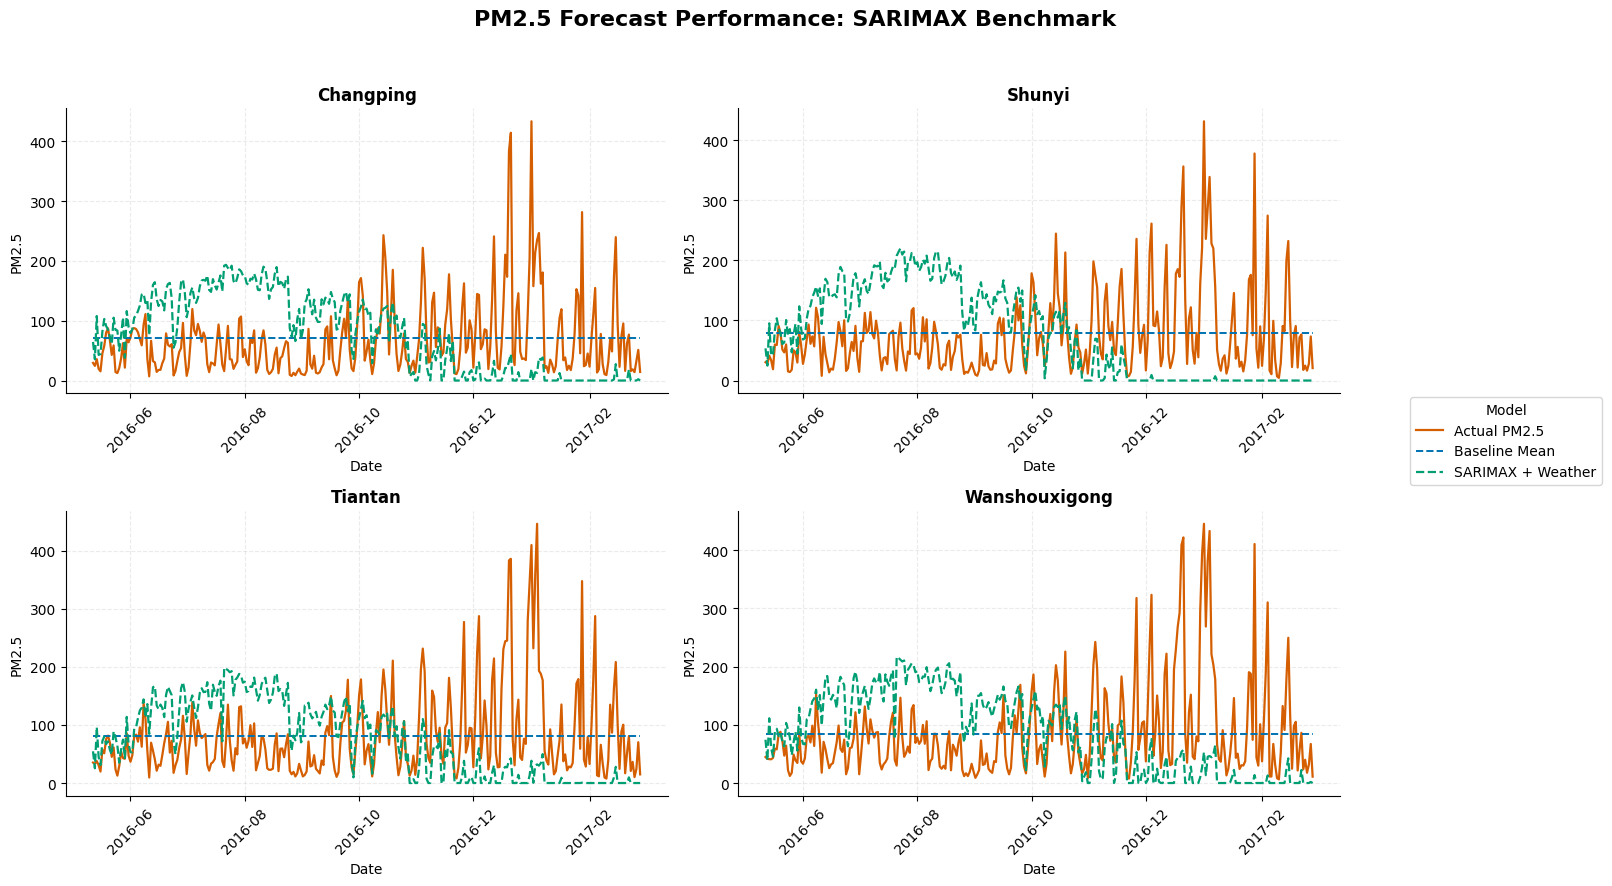

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for i, station_name in enumerate(stations):
    ax = axes[i]

    actual = forecast_store[station_name]["Actual"]
    baseline = forecast_store[station_name]["Baseline"]
    sarimax_pred = forecast_store[station_name]["SARIMAX"]

    ax.plot(actual.index, actual.values, label="Actual PM2.5", color="#D55E00", linewidth=1.6)
    ax.plot(baseline.index, baseline.values, label="Baseline Mean", color="#0072B2", linestyle="--", linewidth=1.4)
    ax.plot(sarimax_pred.index, sarimax_pred.values, label="SARIMAX + Weather", color="#009E73", linestyle="--", linewidth=1.6)

    ax.set_title(station_name, fontsize=12, weight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("PM2.5")

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)

    ax.grid(True, linestyle="--", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for j in range(len(stations), len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Model",
    loc="center left",
    bbox_to_anchor=(0.88, 0.5),
    frameon=True
)

fig.suptitle(
    "PM2.5 Forecast Performance: SARIMAX Benchmark",
    fontsize=16,
    weight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])

output_path = FIG_DIR / "sarimax_weather_forecast_all_stations.png"
plt.savefig(output_path, bbox_inches="tight", dpi=300)

print("Saved:", output_path)

plt.show()
plt.close()

# Final Comparison

## 19. Final Model Comparison and Results Summary

In [19]:
all_results_df = pd.concat(
    [
        results_df,
        sarimax_results_df.groupby("Model")[["RMSE", "MAE", "R2"]].mean().reset_index()
    ],
    ignore_index=True
)

all_results_df = all_results_df.sort_values("RMSE").reset_index(drop=True)

display(all_results_df)

output_results_path = RESULT_DIR / "final_model_results.csv"
all_results_df.to_csv(output_results_path, index=False)
print("Saved final model results to:", output_results_path)


,Model,RMSE,MAE,R2
0,Random Forest,14.956977,8.025153,0.971054
1,Tuned Random Forest,15.187345,8.171056,0.970156
2,Linear Regression,19.392082,11.181764,0.951343
3,Time-Series Baseline Mean,71.334368,50.001298,-0.001985
4,Baseline Mean,88.210233,61.114137,-0.006779
5,SARIMAX + Weather,104.014548,80.528134,-1.164374


Saved final model results to: /content/drive/MyDrive/CMP7005_project/reproducible/results/final_model_results.csv
